# Forecasting Evaluation

## Overview

Evaluating time series forecasts requires special care because observations are not exchangeable — the temporal order matters. Standard k-fold cross-validation cannot be used directly.

**Time series CV approaches:**

| Approach | Description | Use when |
|---|---|---|
| Train/test split | Single fixed split at a time point | Quick baseline |
| Walk-forward CV | Expanding or rolling window | Standard best practice |
| Blocked CV | Fixed-size blocks, no overlap | Large datasets |

**Metrics:**

| Metric | Robust to | Avoid when |
|---|---|---|
| RMSE | — | Outliers dominate |
| MAE | Outliers | Comparing across series |
| MASE | Scale, naive comparison | — |
| MAPE | — | Values near zero |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

rng = np.random.default_rng(42)
dates = pd.date_range("2010-01-01", periods=180, freq="MS")
trend    = np.linspace(2.5, 4.5, 180)
seasonal = 0.8*np.sin(2*np.pi*np.arange(180)/12)
noise    = rng.normal(0, 0.25, 180)
ts = pd.Series(trend+seasonal+noise, index=dates, name="nitrate")
print(f"Series: {len(ts)} observations, {ts.index[0].date()} to {ts.index[-1].date()}")

Series: 180 observations, 2010-01-01 to 2024-12-01


---
## Train/Test Split

In [2]:
HORIZON = 24
train, test = ts.iloc[:-HORIZON], ts.iloc[-HORIZON:]
# Naive seasonal benchmark: last year same month
nb_fc = pd.Series(
    [train.iloc[-(12-i%12)] for i in range(HORIZON)],
    index=test.index
)
hw_fc = (ExponentialSmoothing(train, trend="add", seasonal="add",
    seasonal_periods=12, initialization_method="estimated")
    .fit(optimized=True).forecast(HORIZON))
for name, fc in [("Seasonal Naive", nb_fc), ("Holt-Winters", hw_fc)]:
    rmse = np.sqrt(mean_squared_error(test, fc))
    mae  = mean_absolute_error(test, fc)
    # MASE: MAE relative to naive benchmark
    naive_mae = mean_absolute_error(train.iloc[12:], train.shift(12).dropna())
    mase = mae / naive_mae
    print(f"{name:20s}: RMSE={rmse:.4f}, MAE={mae:.4f}, MASE={mase:.4f}")

Seasonal Naive      : RMSE=0.4180, MAE=0.3327, MASE=1.2539
Holt-Winters        : RMSE=0.2353, MAE=0.2002, MASE=0.7547


---
## Walk-Forward (Expanding Window) Cross-Validation

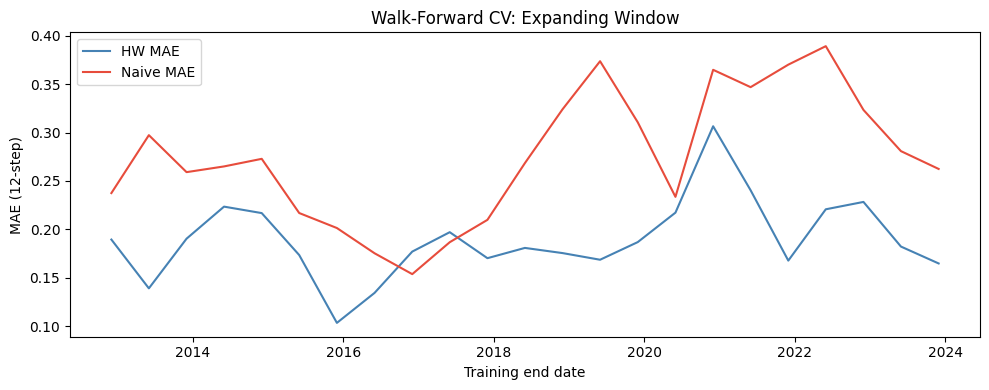

Mean HW MAE:    0.1892
Mean Naive MAE: 0.2749


In [3]:
min_train = 36  # minimum training length
horizon   = 12  # one-year-ahead forecast
hw_errors, naive_errors = [], []
cv_dates = []
for end in range(min_train, len(ts)-horizon+1, 6):  # step by 6 months
    tr = ts.iloc[:end]
    te = ts.iloc[end:end+horizon]
    if len(te) < horizon:
        break
    # Holt-Winters
    try:
        fc = (ExponentialSmoothing(tr, trend="add", seasonal="add",
              seasonal_periods=12, initialization_method="estimated")
              .fit(optimized=True).forecast(horizon))
        hw_errors.append(mean_absolute_error(te, fc))
    except:
        hw_errors.append(np.nan)
    # Seasonal naive
    nb = pd.Series([tr.iloc[-(12-i%12)] for i in range(horizon)], index=te.index)
    naive_errors.append(mean_absolute_error(te, nb))
    cv_dates.append(tr.index[-1])
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(cv_dates, hw_errors,    color="steelblue", lw=1.5, label="HW MAE")
ax.plot(cv_dates, naive_errors, color="#e74c3c",   lw=1.5, label="Naive MAE")
ax.set_xlabel("Training end date"); ax.set_ylabel("MAE (12-step)")
ax.set_title("Walk-Forward CV: Expanding Window")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Mean HW MAE:    {np.nanmean(hw_errors):.4f}")
print(f"Mean Naive MAE: {np.nanmean(naive_errors):.4f}")

---
## Forecast Horizon Profile

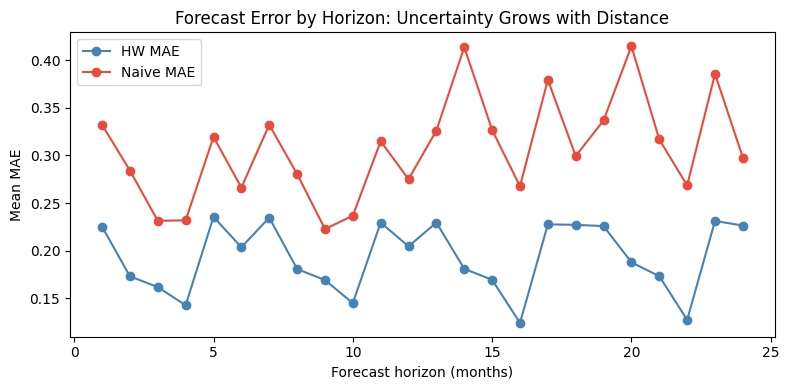

In [4]:
# How does error grow with forecast horizon?
horizons = range(1, 25)
hw_by_h, naive_by_h = [], []
for h in horizons:
    errs_hw, errs_nb = [], []
    for end in range(48, len(ts)-h+1, 6):
        tr = ts.iloc[:end]
        actual = ts.iloc[end+h-1]
        try:
            fc_h = (ExponentialSmoothing(tr, trend="add", seasonal="add",
                    seasonal_periods=12, initialization_method="estimated")
                    .fit(optimized=True).forecast(h))
            errs_hw.append(abs(actual - fc_h.iloc[-1]))
        except:
            pass
        nb_val = tr.iloc[-(12-(h-1)%12)]
        errs_nb.append(abs(actual - nb_val))
    hw_by_h.append(np.nanmean(errs_hw))
    naive_by_h.append(np.mean(errs_nb))
plt.figure(figsize=(8,4))
plt.plot(horizons, hw_by_h,    "o-", color="steelblue", lw=1.5, label="HW MAE")
plt.plot(horizons, naive_by_h, "o-", color="#e74c3c",   lw=1.5, label="Naive MAE")
plt.xlabel("Forecast horizon (months)"); plt.ylabel("Mean MAE")
plt.title("Forecast Error by Horizon: Uncertainty Grows with Distance")
plt.legend(); plt.tight_layout(); plt.show()

---
## Residual Autocorrelation Check

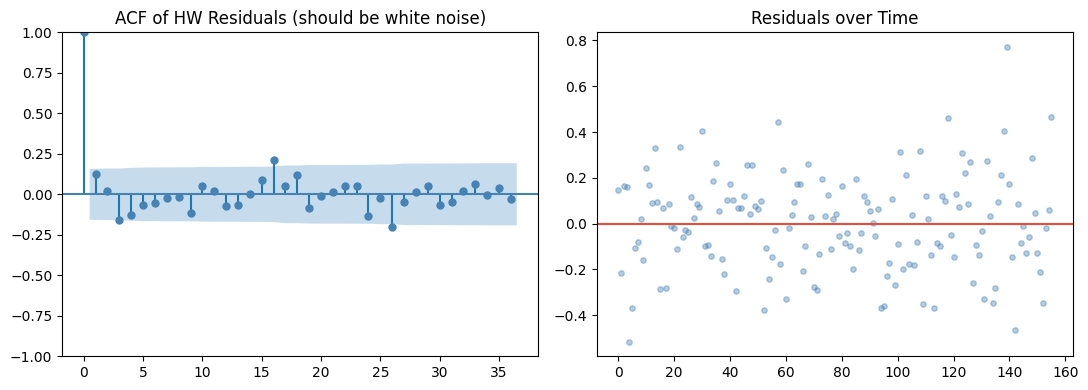

Ljung-Box (H0: white noise residuals):
      lb_stat  lb_pvalue
12  14.105000   0.294054
24  32.608479   0.112608


In [5]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
hw_fit = (ExponentialSmoothing(train, trend="add", seasonal="add",
    seasonal_periods=12, initialization_method="estimated").fit(optimized=True))
resid = hw_fit.resid.dropna()
fig, axes = plt.subplots(1,2,figsize=(11,4))
plot_acf(resid, lags=36, ax=axes[0], color="steelblue")
axes[0].set_title("ACF of HW Residuals (should be white noise)")
axes[1].scatter(range(len(resid)), resid, alpha=0.4, s=15, color="steelblue")
axes[1].axhline(0, color="#e74c3c", lw=1.5)
axes[1].set_title("Residuals over Time")
plt.tight_layout(); plt.show()
lb = acorr_ljungbox(resid, lags=[12,24], return_df=True)
print("Ljung-Box (H0: white noise residuals):")
print(lb)

---

## Common Pitfalls

**1. Using standard k-fold cross-validation for time series**  
Random k-fold splits allow future data to appear in training folds, leaking information. Always use walk-forward (expanding or rolling window) CV where training data strictly precedes test data at every fold.

**2. Reporting only RMSE without a naive benchmark**  
RMSE is scale-dependent and meaningless in isolation. A seasonal naive forecast is the minimum acceptable benchmark. MASE (MAE divided by naive MAE) directly quantifies improvement over naive and is scale-independent.

**3. Evaluating only at a single fixed horizon**  
A model may perform well at 1-step-ahead but poorly at 12-step-ahead. Always report performance across a range of horizons, especially when the forecast will be used at multiple lead times.

**4. Not checking forecast residuals for autocorrelation**  
Autocorrelated residuals indicate the model has not captured all temporal structure — the leftovers are predictable and should have been modelled. Always run the Ljung-Box test and ACF plot on residuals.

**5. Selecting the best model based on in-sample AIC rather than walk-forward CV error**  
AIC penalises complexity but is an in-sample metric. Models with lower AIC do not necessarily forecast better out-of-sample. Always use walk-forward CV error as the primary model selection criterion.
---
*python_methods_library - Samantha McGarrigle*